# Portfolio Constraints and Rebalancing

In this section, we focus on determining the optimal portfolio rebalancing frequency while considering constraints such as maximum leverage and Value at Risk (VaR).

Finally, the code evaluates the quality of replication using metrics such as tracking error, information ratio, turnover, and the impact of transaction costs.

## 0. Imports

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
import pickle
import os
import itertools
import warnings

from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import MinMaxScaler
from itertools import product

# Disable error messages
warnings.filterwarnings('ignore')

In [2]:
# Download the Excel file
file_path = os.path.join(os.getcwd(), 'Dataset3_PortfolioReplicaStrategy.xlsx')
print(f'Loading dataset from: {file_path}')

# Read the Excel file and convert it to a DataFrame
# header=0 indicates that the first row contains the column names
df = pd.read_excel(file_path, header=0)

# Rename the first column "Date"
df = df.rename(columns={df.columns[0]: 'Date'})

# Convert its format into a real date
df['Date'] = pd.to_datetime(df['Date'])

# Replace the index axis with the date axis, 
# Allow usto keep this information without considering it as features
data = df.set_index('Date')

# We create a dictionary that links the abbreviations in the dataset to their meanings
# Only the first 4 elements of this dictionary are stock market indices.
variable_info = {
    'MXWO':    'MSCI World (Developed Equity)',
    'MXWD':    'MSCI World All Country',
    'LEGATRUU':'Bloomberg Global Aggregate Bond',
    'HFRXGL':  'HFRX Global Hedge Fund Index',
    'RX1':   'Bund (10Y Ger)',
    'TY1':   '10Y US Treasury',
    'GC1':   'Gold',
    'CO1':   'Brent Crude Oil',
    'ES1':   'S&P 500',
    'VG1':   'Eurostoxx 50',
    'NQ1':   'Nasdaq 100',
    'LLL1':  'MSCI Emerging Markets',
    'TP1':   'Topix (Japan)',
    'DU1':   '2Y German Govt (Schatz)',
    'TU2':   '2Y US Treasury',
}

print('Shape:', data.shape)
data.head(15)

Loading dataset from: C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase3\Fintech\BC3\Dataset3_PortfolioReplicaStrategy.xlsx
Shape: (705, 15)


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.00,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.00,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.00,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.00,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.00,2035.50,1225.2,1472.5,103.800,104.945312
2007-11-27,1561.93,395.11,361.7651,1325.03,115.08,113.953125,814.0,92.52,1426.50,4241.00,2032.50,1196.2,1485.0,103.925,105.101562
2007-12-04,1593.08,404.26,361.2404,1331.55,115.18,114.656250,801.3,89.53,1463.25,4351.00,2062.25,1240.0,1512.0,103.730,105.312500
2007-12-11,1619.77,411.45,357.3778,1337.57,113.74,114.390625,811.4,89.99,1478.00,4458.00,2090.00,1239.0,1568.0,103.585,105.171875
2007-12-18,1556.84,394.00,353.4098,1323.53,113.18,113.640625,803.0,90.12,1455.75,4317.00,2029.25,1180.5,1467.5,103.345,104.828125


When constructing a replicating portfolio, we deliberately exclude the assets that belong to the target (unknown) portfolio from the set of admissible instruments. This constraint prevents trivial solutions where the optimizer would simply select the same securities, leading to perfect but uninformative replication.

In [3]:
# Define an initial target portfolio that we will try to replicate
target_portfolio = {
    'HFRXGL':  0.50,
    'MXWO':    0.25,
    'LEGATRUU': 0.25,
}

# Here we define all the authorized assets in which we can invest to replicate the target portfolio
authorized_assets = [
    'RX1','TY1','GC1','CO1',
    'ES1','VG1','NQ1','LLL1',
    'TP1','DU1','TU2'
]

Now, we will calculate the yield of the target_portfolio and create a dataframe named "Target portfolio performance"  containing all his data thanks to the formula : 

$$
r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}
$$

Then we will compute the Portfolio return : 

$$
r^{\text{target}}_t = \sum_{i} w_i \cdot r_{i,t}
$$

where $w_i$ represent the weight of each asset in the portfolio

In [4]:
target_assets_returns = data[list(target_portfolio.keys())].pct_change().dropna()
# We delete the first raw as P_i,-1 is not define

target_returns = sum(target_assets_returns [c] * w for c, w in target_portfolio.items()).to_frame(name='Target portfolio returns')

target_assets_returns.head()

,HFRXGL,MXWO,LEGATRUU
Date,,,
2007-10-30,0.009601,0.018642,0.006646
2007-11-06,0.002705,-0.007392,0.004636
2007-11-13,-0.009587,-0.030141,0.008600
2007-11-20,-0.008871,-0.019397,0.006223
2007-11-27,-0.007624,-0.005609,0.006456


In [5]:
target_returns.head()

,Target portfolio returns
Date,
2007-10-30,0.011122
2007-11-06,0.000664
2007-11-13,-0.010179
2007-11-20,-0.007729
2007-11-27,-0.003600


### Portfolio cumulative performance

To analyze the performance of the target portfolio over time, we convert returns into a cumulative value i.e the cumulative product of returns:
Given the return of asset $i$ at time $t$:
$$
V_t = \prod_{s=1}^{t} (1 + r^{\text{target}}_s)
$$

This transformation allows us to interpret returns as the evolution of a portfolio value over time, starting from an initial value (typically 1 or 100). The resulting time series can then be plotted to visualize the growth and volatility of the portfolio.

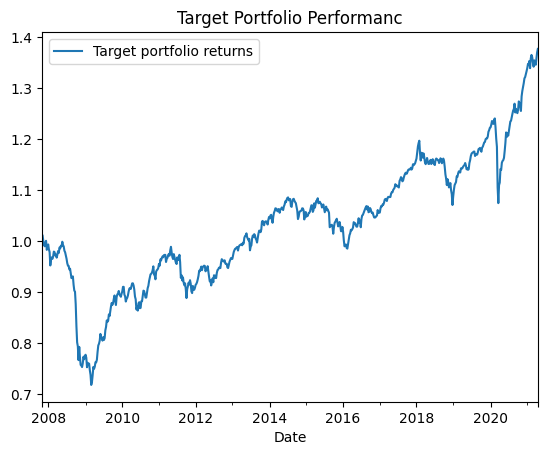

In [6]:
target_cum = (1 + target_returns).cumprod()
target_cum.plot(title="Target Portfolio Performanc");

In [7]:
# We calculate the yield of the authorized financial assets and creat a dataframe containing all his data 
asset_returns = data[authorized_assets].pct_change()
common_dates = asset_returns.index.intersection(target_returns.index)
asset_returns = asset_returns.loc[common_dates]
target_returns  = target_returns.loc[common_dates]

In [8]:
asset_returns.head()

,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,
2007-10-30,0.000792,0.001272,0.037945,0.055401,0.006883,0.018894,0.002599,0.028671,0.025470,0.000242,0.000904
2007-11-06,0.000000,0.001977,0.045189,0.066560,-0.007161,-0.011394,0.007102,-0.002946,-0.021732,0.000000,0.002258
2007-11-13,0.004921,0.007610,-0.029633,-0.047502,-0.027377,-0.023051,-0.074659,-0.037121,-0.085687,0.001789,0.002478
2007-11-20,0.003236,0.012867,-0.009512,0.074975,-0.025114,-0.006246,-0.015120,-0.036035,0.022215,0.001979,0.006142
2007-11-27,0.003138,0.007042,0.028557,-0.031103,-0.013485,-0.012803,-0.001474,-0.023670,0.008489,0.001204,0.001489


In [9]:
X = asset_returns
y = target_returns

dates = X.index.to_numpy()
X_values = X.values
y_values = y.values.reshape(-1)

asset_names = X.columns.tolist()

print(f"X shape: {X.shape}")
print(f"y shape: {y_values.shape}")
print(f"dates: {dates[:10]}")

X shape: (704, 11)
y shape: (704,)
dates: ['2007-10-30T00:00:00.000000000' '2007-11-06T00:00:00.000000000'
 '2007-11-13T00:00:00.000000000' '2007-11-20T00:00:00.000000000'
 '2007-11-27T00:00:00.000000000' '2007-12-04T00:00:00.000000000'
 '2007-12-11T00:00:00.000000000' '2007-12-18T00:00:00.000000000'
 '2007-12-25T00:00:00.000000000' '2008-01-01T00:00:00.000000000']


## Value At Risk

To assess the risk of the portfolio, we compute the Value at Risk (VaR). The VaR at a given confidence level $\alpha $ represents the maximum expected loss over a specified time horizon under normal market conditions. Formally, assuming normally distributed returns, it can be written as:

$$
\text{VaR}_{\alpha} = - z_{\alpha} \cdot \sigma \cdot \sqrt{T}
$$

where $ z_{\alpha}$ is the quantile of the standard normal distribution, $ \sigma$ is the volatility of returns, and $\ T$ is the time horizon. For example, a VaR at 1% of 5% means that there is only a 1% probability that losses exceed 5% over the chosen period. We compute the VaR to quantify downside risk, compare the risk profiles of different portfolios, and ensure that the level of potential loss remains acceptable given the investment strategy.

In [10]:
def calculate_var_gaussian(y_values, confidence=0.01, horizon=4):
    sigma = np.std(y_values)
    z_score = stats.norm.ppf(confidence)
    return -z_score * sigma * np.sqrt(horizon)

In [11]:
var_target = calculate_var_gaussian(y_values)
print(var_target)

0.040805331647495766


Over a period of approximately one month, there is a 1% chance that the portfolio will lose more than 4.08%. In other words, in 99% of cases, the monthly loss should be less than 4.08%, according to the model used

However, this test relies on the assumption that returns follow a normal distribution

In [12]:
def plot_return_distribution(y_values, bins=50):
    
    # Normal parameters
    mu = np.mean(y_values)
    sigma = np.std(y_values)
    
    # Plot
    plt.figure(figsize=(10,6))
    
    sns.histplot(y_values, bins=bins, stat='density', kde=True, alpha=0.6)
    
    # Theorical curve 
    x = np.linspace(min(y_values), max(y_values), 1000)
    normal_pdf = stats.norm.pdf(x, mu, sigma)
    plt.plot(x, normal_pdf, 'r', linewidth=2, label='Normal distribution')
    
    plt.title("Distribution of Target Portfolio Returns")
    plt.xlabel("Returns")
    plt.ylabel("Density")
    plt.legend()
    
    plt.show()

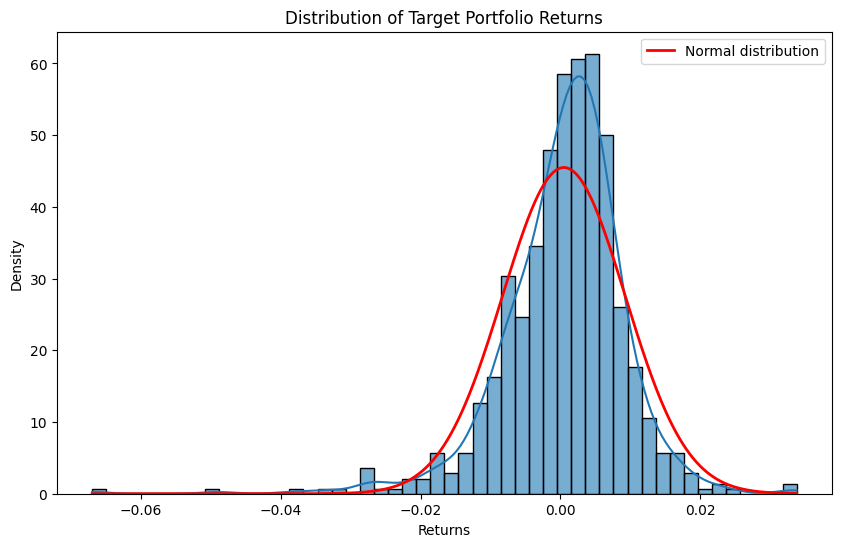

In [13]:
plot_return_distribution(y_values)

We observe that the returns of the target portfolio do not exactly follow a Gaussian distribution. Let's perform some statistical tests, such as the Bera-Jarque test, which compares the skewness and kurtosis of the distribution with those of a normal distribution. For a Gaussian distribution, we expect to find: skewness = 0 (symmetric distribution) and a kurtosis of 3. If the test fails, we will then adapt our VaR test by directly using the observed distribution of returns.

This approach does not assume a normal distribution: it relies directly on the empirical distribution of observed returns.

Because we want to estimate a one-month VaR and our data are weekly, we first compute rolling compounded returns over 4 weeks:

$$
R_{t,t+4} = \prod_{s=t}^{t+3} (1+r_s) - 1
$$

where $r_s$ is the weekly return at time $s$


Then, the historical VaR at the 1% level is obtained by taking the 1% quantile of the distribution of these 4-week returns:

$$
\text{VaR}_{1\%} = -Q_{1\%}(R_{t,t+4})
$$

In [14]:
def test_normality(y_values, alpha=0.05):
    
    results = {}
    
    stat_jb, p_jb = stats.jarque_bera(y_values)
    results['Jarque-Bera'] = {
        'stat': stat_jb,
        'p_value': p_jb,
        'normal': p_jb > alpha
    }
    
    return results

In [15]:
results = test_normality(y_values)

for test, res in results.items():
    print(f"{test}: p-value = {res['p_value']:.5f} Gaussian distribution = {res['normal']}")

Jarque-Bera: p-value = 0.00000 Gaussian distribution = False


As expected, the hypothesis of a Gaussian distribution is rejected.

In [16]:
def calculate_historical_var(y_values, confidence=0.01, horizon=4):

    y_values = np.asarray(y_values, dtype=float)
    returns = pd.Series(y_values[~np.isnan(y_values)])

    horizon_returns = (1 + returns).rolling(window=horizon).apply(np.prod, raw=True) - 1

    horizon_returns = horizon_returns.dropna()

    # Historical quantile
    var = -np.quantile(horizon_returns, confidence)

    return var


In [17]:
var_hist_target = calculate_historical_var(y_values, confidence=0.01, horizon=4)

print(f"Historical VaR 1% over 4 weeks: {var_hist_target:.4%}")

Historical VaR 1% over 4 weeks: 5.9200%


## Exposure and VaR control

We also compute the leverage of the replicating portfolio in order to control how much market exposure the strategy takes. In this notebook, leverage is measured using the gross exposure, defined as the sum of the absolute values of the portfolio weights:

$$
GE = \sum_i |w_i|
$$

This measure captures the total exposure of the portfolio, including both long and short positions. For example, a gross exposure of $1.0$ means that the portfolio is fully invested with no leverage, while a gross exposure of $1.5$ means that the portfolio has 150% exposure to the market.

To avoid unrealistic or overly aggressive portfolios, we impose a maximum gross exposure. If the portfolio exceeds this limit, all weights are rescaled proportionally:

$$
w_i^{new} = w_i \times \frac{GE_{\max}}{GE}
$$

This keeps the relative structure of the portfolio unchanged while reducing its overall exposure. We also check whether the portfolio risk, measured by VaR, exceeds a maximum acceptable level. If the VaR is too high, the weights are rescaled again so that the portfolio remains within the chosen risk limit.

In [18]:
import numpy as np

def apply_gross_exposure_cap(weights, max_gross_exposure):

    weights = np.asarray(weights, dtype=float)

    gross_exposure = np.sum(np.abs(weights))
    scaling_factor = 1.0

    if gross_exposure > max_gross_exposure:
        scaling_factor = max_gross_exposure / gross_exposure
        weights = weights * scaling_factor
        gross_exposure = np.sum(np.abs(weights))

    return weights, scaling_factor, gross_exposure

In [19]:
def apply_var_cap(
    weights,
    X_values,
    var_confidence=0.01,
    var_horizon=4,
    max_var=0.08,
    step=0.01,
    min_scaling=0.0
):


    scaling = 1.0
    history = []

    while scaling >= min_scaling:

        weights_scaled = weights * scaling
        portfolio_returns = X_values @ weights_scaled

        var_value = calculate_historical_var(
            portfolio_returns,
            confidence=var_confidence,
            horizon=var_horizon
        )

        history.append({
            "scaling": scaling,
            "VaR": var_value
        })

        if not np.isnan(var_value) and var_value <= max_var:
            history_df = pd.DataFrame(history)
            return weights_scaled, scaling, var_value, history_df

        scaling -= step

    history_df = pd.DataFrame(history)

    return weights * min_scaling, min_scaling, history_df["VaR"].iloc[-1], history_df

Example of use if the weights of our replicated portfolio are:

In [20]:
weights = np.array([
    0.10, 0.10, 0.10, 0.10, 0.10,
    0.10, 0.10, 0.10, 0.10, 0.05, 0.05
])

In [21]:
weights_after_var, var_scaling, final_var, var_history = apply_var_cap(
    weights=weights,
    X_values=X_values,
    var_confidence=0.01,
    var_horizon=4,
    max_var=0.08,
    step=0.005
)

print(f"Final scaling factor: {var_scaling}")
print(f"Final historical VaR: {final_var}")
print(f"Weights rescaled: {weights_after_var}")

Final scaling factor: 0.8549999999999999
Final historical VaR: 0.07959282649782051
Weights rescaled: [0.0855  0.0855  0.0855  0.0855  0.0855  0.0855  0.0855  0.0855  0.0855
 0.04275 0.04275]


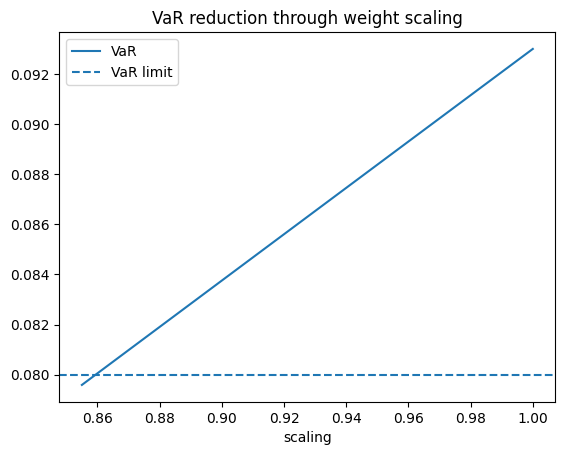

In [22]:
ax = var_history.plot(x="scaling", y="VaR", title="VaR reduction through weight scaling")
ax.axhline(0.08, linestyle="--", label="VaR limit")
ax.legend()
plt.show()

## Portfolio turnover

We compute the portfolio turnover to measure how much the portfolio weights change between two consecutive rebalancing dates. For each rebalancing period, the turnover is calculated as the sum of the absolute changes in weights:

$$
Turnover_t = \sum_i |w_{i,t} - w_{i,t-1}|
$$

where $w_{i,t}$ is the weight of asset $i$ at time $t$. A high turnover means that the portfolio composition changes significantly over time, which may imply higher transaction costs. A low turnover means that the portfolio is more stable and requires fewer trades. The function returns the average turnover across all rebalancing periods.

In [23]:
def compute_turnover(weights_history):
    if isinstance(weights_history, pd.DataFrame):
        vals = weights_history.values
        diffs = [np.sum(np.abs(vals[t] - vals[t-1])) for t in range(1, len(vals))]
    else:
        diffs = [np.sum(np.abs(weights_history[t] - weights_history[t-1]))
                 for t in range(1, len(weights_history))]
    return np.mean(diffs) if diffs else 0.0


## Performances of the replicated Portfolio

In [24]:
def compute_metrics(
    asset_returns, 
    target_returns,
    weights_history,
    
    # Cost for one transaction (necessary if we want to balance our portfolio)
    cost_bps=5, 
    var_values=None
):

    ann  = 52
    diff = asset_returns - target_returns

    rep_ann = asset_returns.mean() * ann
    tgt_ann = target_returns.mean() * ann
    rep_vol = asset_returns.std() * np.sqrt(ann)
    tgt_vol = target_returns.std() * np.sqrt(ann)
    
    TE = diff.std() * np.sqrt(ann)
    IR = (rep_ann - tgt_ann) / TE if TE > 0 else np.nan
    p = asset_returns.corr(target_returns)
    sharpe = rep_ann / rep_vol if rep_vol > 0 else np.nan

    wh_vals = weights_history.values if isinstance(weights_history, pd.DataFrame) else weights_history
    GE_mean = np.mean([np.sum(np.abs(w)) for w in wh_vals])
    avg_var = np.nanmean(var_values) if var_values else np.nan

    # Turnover and costs
    turnover = compute_turnover(weights_history)
    cost_per_period = cost_bps / 10_000 * turnover
    net_returns = asset_returns - cost_per_period
    net_ann = net_returns.mean() * ann
    net_TE = (net_returns - target_returns).std() * np.sqrt(ann)
    net_IR = (net_ann - tgt_ann) / net_TE if net_TE > 0 else np.nan

    # Max Drawdown
    cum = (1 + asset_returns).cumprod()
    mdd = (1 - cum / cum.cummax()).max()

    # Store metrics in a dictionary
    metrics = {
        "IR": IR,
        "TE": TE,
        "p": p,
        "GE": GE_mean,
        "VaR": avg_var,
        "turnover": turnover,
        "net_IR": net_IR,
        "net_TE": net_TE,
        "rep_ann": rep_ann,
        "tgt_ann": tgt_ann,
        "rep_vol": rep_vol,
        "tgt_vol": tgt_vol,
        "sharpe": sharpe,
        "mdd": mdd,
        "net_ann": net_ann,
    }

    # Convert dictionary to DataFrame
    metrics_df = pd.DataFrame.from_dict(
        metrics,
        orient="index",
        columns=["Value"]
    )

    metrics_df.index.name = "Metric"

    return metrics_df

In [25]:
# Fake weekly returns for replica and target portfolios
demo_dates = pd.date_range(start="2020-01-01", periods=10, freq="W")

replica_series = pd.Series(
    [0.01, 0.02, -0.01, 0.015, 0.005, -0.02, 0.01, 0.012, -0.005, 0.018],
    index=demo_dates,
    name="replica"
)

target_series = pd.Series(
    [0.008, 0.018, -0.012, 0.014, 0.006, -0.018, 0.011, 0.010, -0.004, 0.016],
    index=demo_dates,
    name="target"
)

# Fake weights history: 3 assets, 10 rebalancing dates
weights_history = [
    np.array([0.40, 0.40, 0.20]),
    np.array([0.42, 0.38, 0.20]),
    np.array([0.41, 0.39, 0.20]),
    np.array([0.43, 0.37, 0.20]),
    np.array([0.44, 0.36, 0.20]),
    np.array([0.45, 0.35, 0.20]),
    np.array([0.46, 0.34, 0.20]),
    np.array([0.45, 0.35, 0.20]),
    np.array([0.44, 0.36, 0.20]),
    np.array([0.43, 0.37, 0.20]),
]

demo_metrics = compute_metrics(
    asset_returns=replica_series,
    target_returns=target_series,
    weights_history=weights_history,
    cost_bps=5,
    var_values=None
)

demo_metrics


,Value
Metric,
IR,2.627721
TE,0.011873
p,0.993919
GE,1.000000
VaR,NaN
turnover,0.024444
net_IR,2.574193
net_TE,0.011873
rep_ann,0.286000


## Rolling backtest and rebalancing

In this backtest, the portfolio weights are recalculated using a rolling training window of 104 weeks, which corresponds to approximately two years of historical data. The portfolio is rebalanced every 4 weeks, meaning that the model estimates new weights only once per month. Between two rebalancing dates, the same weights are kept constant. At each rebalancing date, the model uses only past data to estimate the new portfolio weights, and these weights are then applied to the following out-of-sample period. This makes the backtest more realistic, as it avoids using future information when constructing the replicating portfolio.

## HERE I IMPLEMENTED THE PART THAT REPLICATE THE PORTFOLIO. WE HAVE TO REPLACE THIS PART BY THE REALY WRITTEN BY QIAO I THINK ? 

The function returns the estimated coefficients, interpreted as the weights of the replicating portfolio.

In [26]:
def fit_elastic_net(X_train, y_train, alpha=0.001, l1_ratio=0.5):
    
    scaler_X = MinMaxScaler()
    X_norm   = scaler_X.fit_transform(X_train)
    scaler_y = MinMaxScaler()
    y_norm   = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                       fit_intercept=False, max_iter=10000, tol=1e-4)
    model.fit(X_norm, y_norm)

    # Rescaling vers unités originales
    weights_original = model.coef_ / scaler_X.scale_
    return weights_original

In [27]:
def run_backtest(
    X_values, 
    y_values,
    asset_names,
    dates,
    rolling_window=104,
    rebal_freq=4,
    max_gross_exposure=1.0,
    max_var=0.08,
    step=0.005,
    alpha=0.001,
    l1_ratio=0.5,
    cost_bps=5,
    var_confidence=0.01,
    var_horizon=4,
):

    X_values = np.asarray(X_values)
    y_values = np.asarray(y_values).reshape(-1)

    n_feat = X_values.shape[1]

    weights_list = []
    replica_list = []
    target_list = []
    date_list = []
    var_list = []
    scaling_list = []
    ge_list = []

    current_weights = np.zeros(n_feat)
    last_rebal_idx = -999           

    for i in range(len(X_values) - rolling_window - 1):
        end_idx = i + rolling_window

        if (i - last_rebal_idx) >= rebal_freq:
            X_train = X_values[i:end_idx]
            y_train = y_values[i:end_idx]

            raw_weights = fit_elastic_net(
                X_train, 
                y_train, 
                alpha=alpha, 
                l1_ratio=l1_ratio
            )

            weights_ge, ge_scaling, final_ge = apply_gross_exposure_cap(
                raw_weights,
                max_gross_exposure=max_gross_exposure
            )

            X_hist = X_values[max(0, end_idx - 52):end_idx]

            weights_after_var, var_scaling, final_var, var_history = apply_var_cap(
                weights=weights_ge,
                X_values=X_hist,
                var_confidence=var_confidence,
                var_horizon=var_horizon,
                max_var=max_var,
                step=step
            )

            current_weights = weights_after_var
            scaling = ge_scaling * var_scaling
            var = final_var

            last_rebal_idx = i

        else:
            scaling = 1.0
            hist_rets = replica_list[max(0, len(replica_list)-52):] if replica_list else []

            if len(hist_rets) >= max(12, var_horizon):
                var = calculate_historical_var(
                    hist_rets,
                    confidence=var_confidence,
                    horizon=var_horizon
                )
            else:
                var = np.nan

        next_asset_ret = X_values[end_idx]
        replica_ret = np.dot(next_asset_ret, current_weights)

        replica_list.append(replica_ret)
        target_list.append(float(y_values[end_idx]))
        date_list.append(dates[end_idx])
        weights_list.append(current_weights.copy())
        var_list.append(var)
        scaling_list.append(scaling)
        ge_list.append(np.sum(np.abs(current_weights)))

    replica_returns = pd.Series(replica_list, index=date_list, name="replica")
    target_series = pd.Series(target_list, index=date_list, name="target")

    weights_history = pd.DataFrame(
        weights_list,
        index=date_list,
        columns=asset_names
    )



    metrics_df = compute_metrics(
        replica_returns,
        target_series,
        weights_history,
        cost_bps=cost_bps,
        var_values=var_list
    )

    metadata_df = pd.DataFrame.from_dict(
        {
            "rolling_window": rolling_window,
            "rebal_freq": rebal_freq,
            "max_gross_exposure": max_gross_exposure,
            "max_var": max_var,
            "alpha": alpha,
            "l1_ratio": l1_ratio,
        },
        orient="index",
        columns=["Value"]
    )

    return {
        "weights_history": weights_history,
        "replica_returns": replica_returns,
        "target_returns": target_series,
        "metrics": metrics_df,
        "metadata": metadata_df,
        "var_series": pd.Series(var_list, index=date_list, name="VaR"),
        "ge_series": pd.Series(ge_list, index=date_list, name="Gross Exposure"),
        "scaling_series": pd.Series(scaling_list, index=date_list, name="Scaling"),
    }

## Tested portfolio configurations

We test several portfolio replication configurations by combining different rebalancing frequencies and leverage constraints. The objective is to analyze how portfolio stability, trading frequency, leverage, and risk constraints affect the quality of the replication strategy.

Three rebalancing frequencies are considered:

- **Weekly (1 week):** the portfolio weights are updated every week. This allows the portfolio to react quickly to market changes, but may generate higher turnover and transaction costs.
- **Monthly (4 weeks):** the portfolio is rebalanced once every month. This provides a compromise between responsiveness and portfolio stability.
- **Quarterly (12 weeks):** the portfolio is updated only every three months. This reduces trading activity and turnover, but the portfolio may react more slowly to market changes.

For each rebalancing frequency, we test two leverage constraints using the Gross Exposure measure:

$$
GE = \sum_i |w_i|
$$

- **100% Gross Exposure:** the portfolio is fully invested without leverage.
- **200% Gross Exposure:** the portfolio can use leverage up to twice the invested capital, which corresponds approximately to the European UCITS leverage limit.

The six tested configurations are summarized below:

| Config | Rebalancing Frequency | Maximum Gross Exposure |
|--------|------------------------|-------------------------|
| B1 | Weekly (1w) | 100% |
| B2 | Weekly (1w) | 200% |
| B3 | Monthly (4w) | 100% |
| B4 | Monthly (4w) | 200% |
| B5 | Quarterly (12w) | 100% |
| B6 | Quarterly (12w) | 200% |

These scenarios allow us to study the trade-off between replication quality, transaction costs, leverage, and portfolio risk.

In [28]:
# Configuration grid
CONFIGS = [
    {'label': 'CONFIG 1', 'rebal_freq': 1,  'max_gross_exposure': 1.0, 'desc': 'Weekly / No leverage'},
    {'label': 'CONFIG 2', 'rebal_freq': 1,  'max_gross_exposure': 2.0, 'desc': 'Weekly / 200% cap'},
    {'label': 'CONFIG 3', 'rebal_freq': 4,  'max_gross_exposure': 1.0, 'desc': 'Monthly / No leverage'},
    {'label': 'CONFIG 4', 'rebal_freq': 4,  'max_gross_exposure': 2.0, 'desc': 'Monthly / 200% cap'},
    {'label': 'CONFIG 5', 'rebal_freq': 12, 'max_gross_exposure': 1.0, 'desc': 'Quarterly / No leverage'},
    {'label': 'CONFIG 6', 'rebal_freq': 12, 'max_gross_exposure': 2.0, 'desc': 'Quarterly / 200% cap'},
]

# Common parameters:

rolling_window = 104
max_var = 0.08
step = 0.005
alpha = 0.001
l1_ratio = 0.5
cost_bps = 5
var_confidence = 0.01
var_horizon = 4

results = {}

for config in CONFIGS:
    
    label = config["label"]

    result = run_backtest(
        X_values=X_values,
        y_values=y_values,
        asset_names=asset_names,
        dates=dates, 
        rolling_window=rolling_window,
        rebal_freq=config["rebal_freq"],
        max_gross_exposure=config["max_gross_exposure"],
        max_var=max_var,
        step=step,
        alpha=alpha,
        l1_ratio=l1_ratio,
        cost_bps=cost_bps,
        var_confidence=var_confidence,
        var_horizon=var_horizon
    )

    results[label] = {
        "config": config,
        **result
    }

    met = result["metrics"]

    IR = met.loc["IR", "Value"]
    TE = met.loc["TE", "Value"]
    rho = met.loc["p", "Value"]
    GE = met.loc["GE", "Value"]


rows = []
for label, res in results.items():
    m = res['metrics']
    cfg = res['config']
    rows.append({
        'Config': label,
        'Description': cfg['desc'],
        'Rebal (weeks)': cfg['rebal_freq'],
        'Max GE': f"{cfg['max_gross_exposure']*100:.0f}%",
        'Annual Return': f"{m.loc['rep_ann','Value']*100:+.2f}%",
        'Annual Volatility': f"{m.loc['rep_vol','Value']*100:.2f}%",
        'Sharpe': f"{m.loc['sharpe','Value']:.3f}",
        'Tracking Error': f"{m.loc['TE','Value']*100:.2f}%",
        'Info Ratio (IR)': f"{m.loc['IR','Value']:+.3f}",
        'Correlation': f"{m.loc['p','Value']:.4f}",
        'Avg GE': f"{m.loc['GE','Value']*100:.0f}%",
        'Avg VaR(1%,1M)': f"{m.loc['VaR','Value']*100:.2f}%" if not np.isnan(m.loc['VaR','Value']) else 'N/A',
        'Turnover': f"{m.loc['turnover','Value']:.4f}",
        'Net IR': f"{m.loc['net_IR','Value']:+.3f}",
        'Net TE': f"{m.loc['net_TE','Value']*100:.2f}%",
        'Max Drawdown': f"{m.loc['mdd','Value']*100:.2f}%",
    })

table = pd.DataFrame(rows).set_index('Config')
print('Comparison table taking constraints into account: Trading Cadence and Leverage Cap')
display(table)

Comparison table taking constraints into account: Trading Cadence and Leverage Cap


,Description,Rebal (weeks),Max GE,Annual Return,Annual Volatility,Sharpe,Tracking Error,Info Ratio (IR),Correlation,Avg GE,"Avg VaR(1%,1M)",Turnover,Net IR,Net TE,Max Drawdown
Config,,,,,,,,,,,,,,,
CONFIG 1,Weekly / No leverage,1,100%,+1.92%,2.86%,0.672,3.83%,-0.510,0.7805,19%,1.72%,0.0105,-0.517,3.83%,4.22%
CONFIG 2,Weekly / 200% cap,1,200%,+1.92%,2.86%,0.672,3.83%,-0.510,0.7805,19%,1.72%,0.0105,-0.517,3.83%,4.22%
CONFIG 3,Monthly / No leverage,4,100%,+1.83%,2.98%,0.615,3.85%,-0.530,0.7657,19%,1.60%,0.0060,-0.534,3.85%,4.56%
CONFIG 4,Monthly / 200% cap,4,200%,+1.83%,2.98%,0.615,3.85%,-0.530,0.7657,19%,1.60%,0.0060,-0.534,3.85%,4.56%
CONFIG 5,Quarterly / No leverage,12,100%,+1.93%,2.88%,0.672,3.75%,-0.517,0.7969,19%,1.57%,0.0038,-0.520,3.75%,4.55%
CONFIG 6,Quarterly / 200% cap,12,200%,+1.93%,2.88%,0.672,3.75%,-0.517,0.7969,19%,1.57%,0.0038,-0.520,3.75%,4.55%


The table compares the different portfolio replication strategies tested in the backtest. The table reports several performance, replication, and risk metrics for each strategy.

The displayed metrics include the annualized return and volatility of the replicated portfolio, the Sharpe ratio, the Tracking Error, the Information Ratio, and the correlation with the target portfolio. We also report the average Gross Exposure, the average historical VaR at the 1% confidence level over a one-month horizon, the portfolio turnover, and the maximum drawdown. Finally, net performance metrics such as the Net Information Ratio and Net Tracking Error are computed after taking transaction costs into account.

This comparison allows us to study the trade-off between replication quality, leverage, portfolio stability, transaction costs, and risk management across the different rebalancing frequencies and leverage constraints.

## Analysis of the replication results

The comparison table shows that the different replication strategies produce relatively similar levels of annual return and volatility. The replicated portfolios achieve annualized returns between approximately 1.8% and 1.9%, with annualized volatility close to 3%. The Sharpe ratios remain moderate, around 0.62–0.67, indicating a reasonable but not exceptional risk-adjusted performance.

The replication quality is mainly evaluated through the Tracking Error and the correlation with the target portfolio. The Tracking Error remains relatively stable across all configurations, around 3.7% and 3.9%, while the correlation with the target portfolio stays between 0.76 and 0.80. This suggests that the model is able to capture a significant part of the target portfolio dynamics, although the replication is still imperfect.

One important observation is that increasing the maximum Gross Exposure from 100% to 200% has almost no impact on the results. Configurations with leverage constraints at 100% and 200% produce nearly identical metrics. This indicates that the Elastic Net allocation naturally generates portfolios with relatively low effective leverage, as confirmed by the average Gross Exposure of only about 19% in all cases. In practice, the leverage constraint is therefore not binding in this experiment.

The rebalancing frequency has a more noticeable effect. Weekly rebalancing generates the highest turnover, while quarterly rebalancing significantly reduces trading activity and transaction costs. Despite the lower trading frequency, the quarterly strategies maintain similar or slightly better replication quality, with lower Tracking Error and higher correlation. This suggests that the portfolio weights remain relatively stable over time and do not require frequent updates.

The historical VaR remains low across all configurations, around 1.6%–1.7% over a one-month horizon at the 1% confidence level. This indicates that the replicated portfolios remain relatively conservative in terms of downside risk. Similarly, the maximum drawdown remains limited, around 4%–5%, showing that the strategies experience relatively moderate cumulative losses during stressed periods.

Finally, the Information Ratios are negative for all configurations. This means that the replicated portfolios underperform the target portfolio relative to the level of replication error. Although the portfolios are reasonably correlated with the target, the replication quality is not strong enough to consistently outperform or perfectly track the benchmark.

## Visualizations of the returns for each configuration and the target portfolio

Now we display a graph allowing us to visually compare the target portfolio with the different replication strategies.

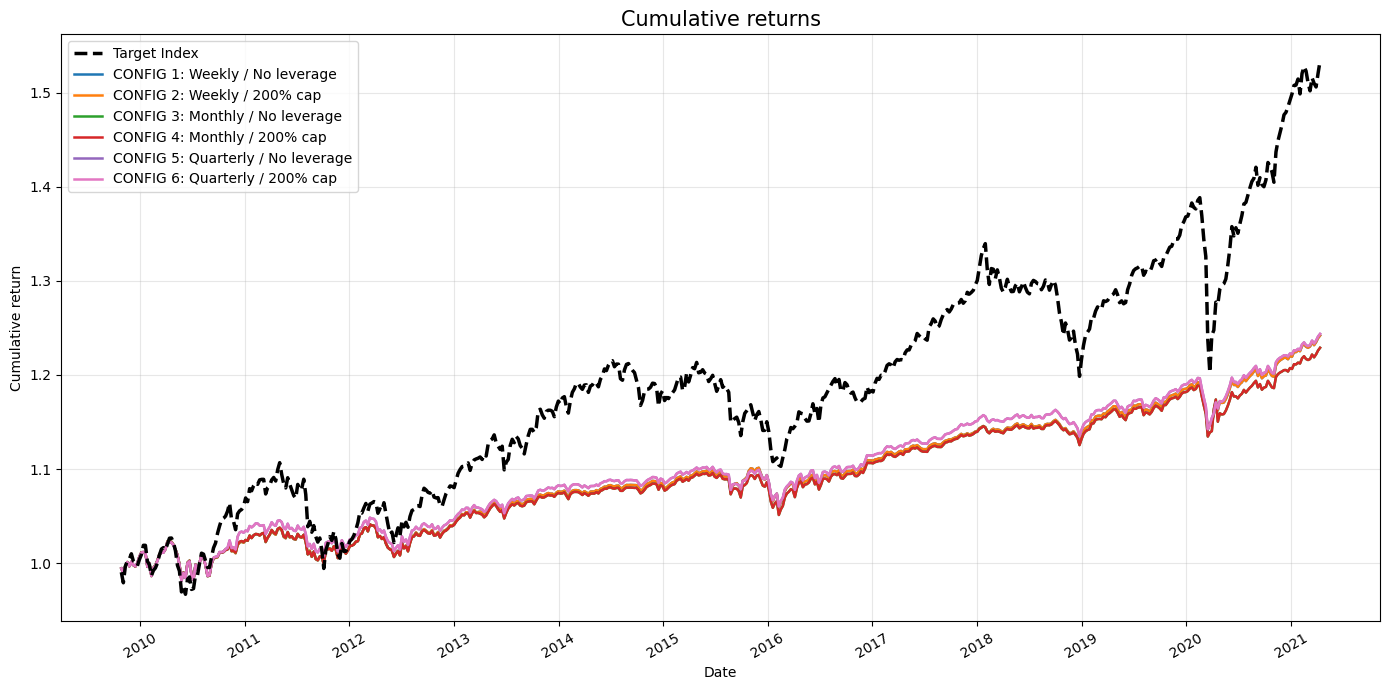

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

# Target
ref = results['CONFIG 1']['target_returns']
cum_target = (1 + ref).cumprod()
ax.plot(cum_target.index, cum_target.values, 'k--', lw=2.5, label='Target Index', zorder=10)

colors = plt.cm.tab10(np.linspace(0, 0.6, 6))
for (label, res), col in zip(results.items(), colors):
    rr  = res['replica_returns']
    cum = (1 + rr).cumprod()
    ax.plot(cum.index, cum.values, lw=1.8, color=col,
            label=f"{label}: {res['config']['desc']}")

ax.set_title('Cumulative returns', fontsize=15)
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative return')
ax.legend(loc='upper left', fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


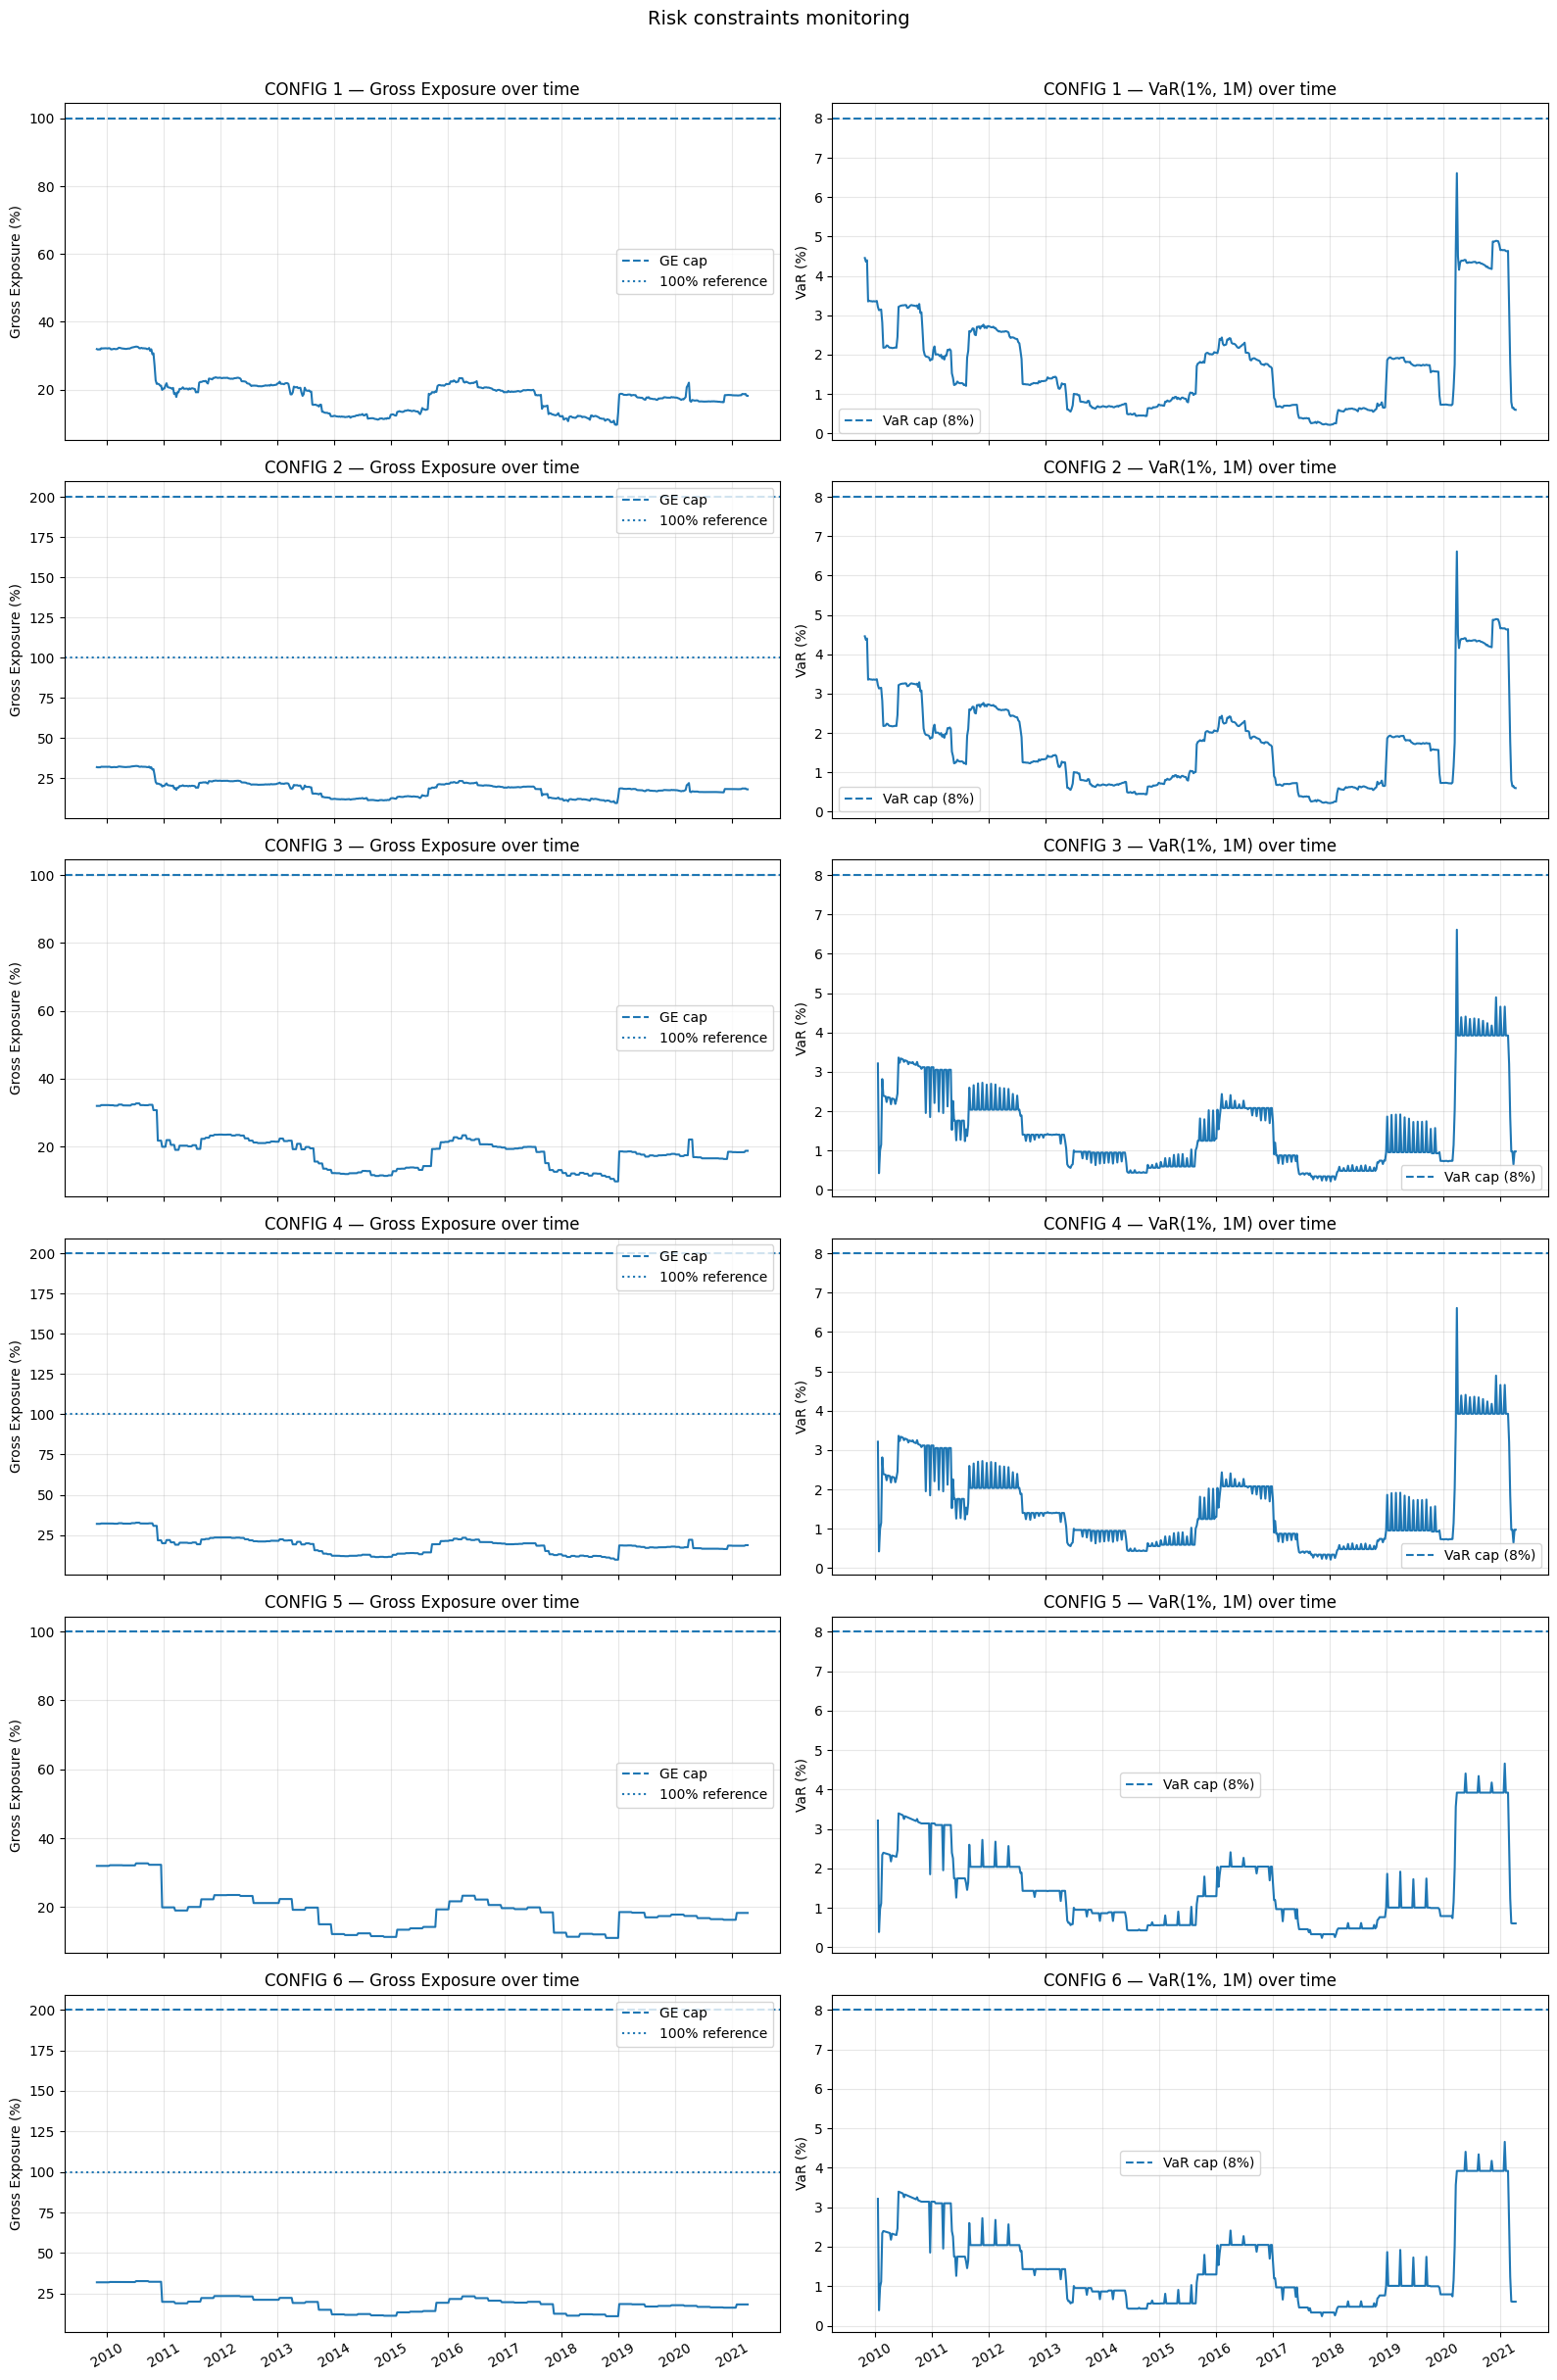

In [30]:
# ── Gross Exposure & VaR pour toutes les configurations ──────────────
n_configs = len(results)

fig, axes = plt.subplots(n_configs, 2, figsize=(16, 4 * n_configs), sharex=True)

# If there is only one config, keep axes 2D
if n_configs == 1:
    axes = np.array([axes])

for ax_row, (label, res) in zip(axes, results.items()):

    # Gross Exposure
    ax_row[0].plot(
        res["ge_series"].index,
        res["ge_series"].values * 100
    )
    ax_row[0].axhline(y=res["config"]["max_gross_exposure"] * 100, linestyle="--", label="GE cap")
    ax_row[0].axhline(y=100, linestyle=":", label="100% reference")
    ax_row[0].set_title(f"{label} — Gross Exposure over time")
    ax_row[0].set_ylabel("Gross Exposure (%)")
    ax_row[0].legend()
    ax_row[0].grid(True, alpha=0.3)

    # VaR
    ax_row[1].plot(
        res["var_series"].index,
        res["var_series"].values * 100
    )
    ax_row[1].axhline(
        y=max_var * 100,
        linestyle="--",
        label=f"VaR cap ({max_var*100:.0f}%)"
    )
    ax_row[1].set_title(f"{label} — VaR(1%, 1M) over time")
    ax_row[1].set_ylabel("VaR (%)")
    ax_row[1].legend()
    ax_row[1].grid(True, alpha=0.3)

for ax in axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Risk constraints monitoring", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

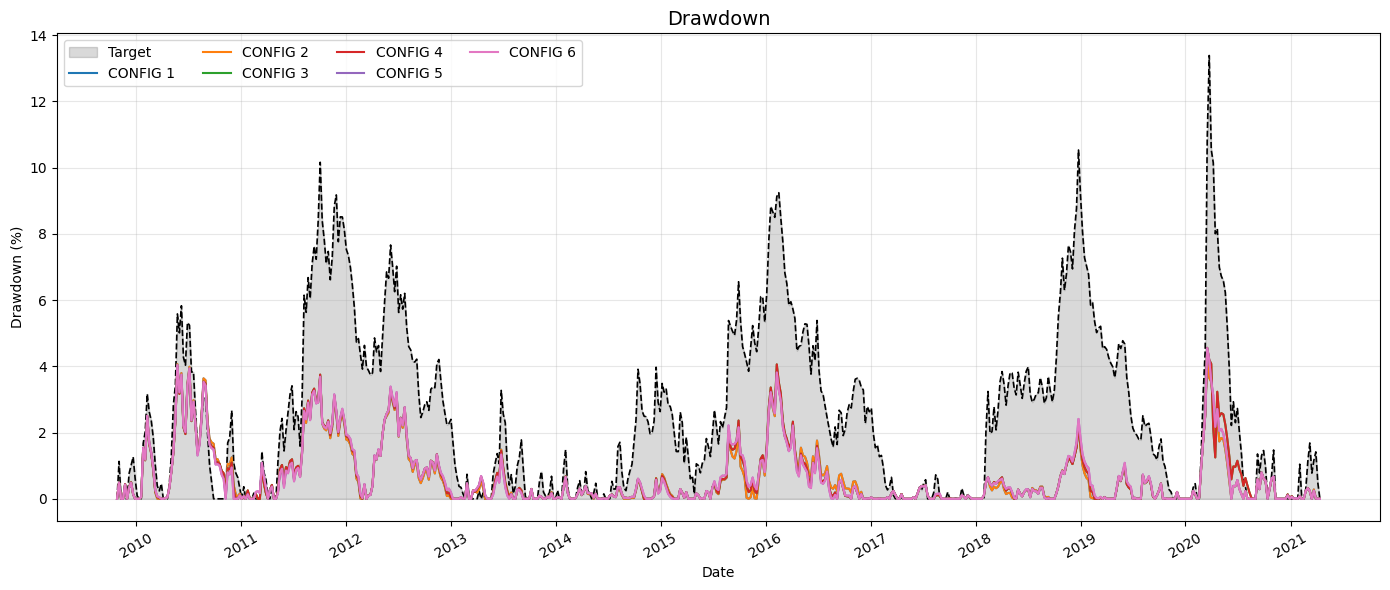

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

cum_target = (1 + results['CONFIG 1']['target_returns']).cumprod()
dd_target  = 1 - cum_target / cum_target.cummax()
ax.fill_between(dd_target.index, dd_target.values * 100, alpha=0.15, color='black', label='Target')
ax.plot(dd_target.index, dd_target.values * 100, 'k--', lw=1.2)

colors = plt.cm.tab10(np.linspace(0, 0.6, 6))
for (label, res), col in zip(results.items(), colors):
    rr  = res['replica_returns']
    cum = (1 + rr).cumprod()
    dd  = 1 - cum / cum.cummax()
    ax.plot(dd.index, dd.values * 100, lw=1.5, color=col, label=label)

ax.set_title('Drawdown', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Drawdown (%)')
ax.legend(ncol=4, fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Portfolio weights dynamics for the best configuration

The following figure displays the evolution of the portfolio weights over time for the best replication strategy, selected according to the highest Information Ratio (IR). To improve readability, only the most significant assets are displayed, based on their average absolute portfolio weight. This visualization allows us to analyze how the allocation evolves through time, identify the dominant assets in the replication strategy, and observe the stability of the portfolio composition across different market periods.

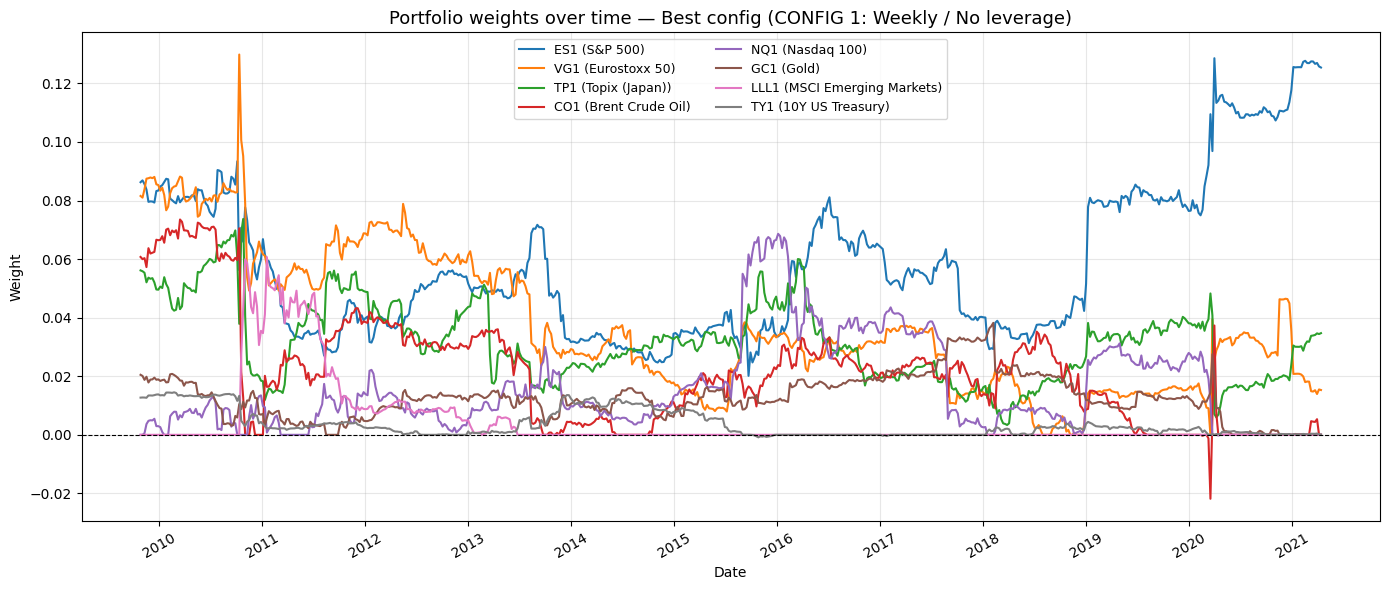

In [32]:
# Best Portfolio Weight, chosen with IR ;
best_label = max(results, key=lambda k: results[k]['metrics'].loc['IR','Value'])
best_wh = results[best_label]['weights_history']

top_cols = best_wh.abs().mean().sort_values(ascending=False).head(8).index

fig, ax = plt.subplots(figsize=(14, 6))
for col in top_cols:
    ax.plot(best_wh.index, best_wh[col].values, lw=1.5,
            label=f'{col} ({variable_info.get(col, col)})')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title(f'Portfolio weights over time — Best config ({best_label}: {results[best_label]["config"]["desc"]})',
             fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Weight')
ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Crisis-window evaluation

Now, we evaluate the performance of each configuration during periods of crisis. We begin by defining the periods during which major crises occurred. Here, we are considering the 2008 financial crisis and the COVID-19 health crisis.

In [33]:
CRISIS_WINDOWS = {
    'GFC (Sep 2008 – Mar 2009)':   ('2008-09-01', '2009-03-31'),
    'COVID (Feb 2020 – Apr 2020)': ('2020-02-01', '2020-04-30'),
}

We set up a function that retrieves the returns of the replicated portfolio and the returns of the target portfolio only for these periods

In [34]:
def evaluate_crisis(replica_series, target_series, start, end):
    
    rep = replica_series.loc[start:end]
    tgt = target_series.loc[start:end]
    if len(rep) == 0:
        return {k: np.nan for k in ['cum_rep','cum_tgt','mdd','corr','te_crisis','var_realized']}

    cum_rep = (1 + rep).prod() - 1
    cum_tgt = (1 + tgt).prod() - 1
    cum_path = (1 + rep).cumprod()
    mdd      = (1 - cum_path / cum_path.cummax()).max()
    corr     = rep.corr(tgt)
    te_c     = (rep - tgt).std() * np.sqrt(52)
    var_r    = calculate_historical_var(rep.values, confidence=0.01, horizon=4)
    return {
        'cum_rep': cum_rep,
        'cum_tgt': cum_tgt,
        'mdd': mdd,
        'corr': corr,
        'te_crisis': te_c,
        'var_realized': var_r,
    }

In [35]:
crisis_rows = []
for label, res in results.items():
    rr  = res['replica_returns']
    tgt = res['target_returns']
    for crisis_name, (start, end) in CRISIS_WINDOWS.items():
        m = evaluate_crisis(rr, tgt, start, end)
        crisis_rows.append({
            'Config': label,
            'Crisis': crisis_name,
            'Description': res['config']['desc'],
            'Replica Return': f"{m['cum_rep']*100:+.1f}%",
            'Target Return': f"{m['cum_tgt']*100:+.1f}%",
            'Max Drawdown': f"{m['mdd']*100:.1f}%",
            'Correlation': f"{m['corr']:.3f}",
            'TE (crisis)': f"{m['te_crisis']*100:.2f}%",
            'VaR realized': f"{m['var_realized']*100:.2f}%",
        })

crisis_df = pd.DataFrame(crisis_rows)
print('CRISIS-WINDOW EVALUATION')
display(crisis_df.set_index(['Crisis', 'Config']))

CRISIS-WINDOW EVALUATION


,,Description,Replica Return,Target Return,Max Drawdown,Correlation,TE (crisis),VaR realized
Crisis,Config,,,,,,,
GFC (Sep 2008 – Mar 2009),CONFIG 1,Weekly / No leverage,+nan%,+nan%,nan%,nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 1,Weekly / No leverage,-1.3%,-6.3%,4.2%,0.717,14.47%,4.06%
GFC (Sep 2008 – Mar 2009),CONFIG 2,Weekly / 200% cap,+nan%,+nan%,nan%,nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 2,Weekly / 200% cap,-1.3%,-6.3%,4.2%,0.717,14.47%,4.06%
GFC (Sep 2008 – Mar 2009),CONFIG 3,Monthly / No leverage,+nan%,+nan%,nan%,nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 3,Monthly / No leverage,-2.1%,-6.3%,4.6%,0.593,14.78%,4.42%
GFC (Sep 2008 – Mar 2009),CONFIG 4,Monthly / 200% cap,+nan%,+nan%,nan%,nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 4,Monthly / 200% cap,-2.1%,-6.3%,4.6%,0.593,14.78%,4.42%
GFC (Sep 2008 – Mar 2009),CONFIG 5,Quarterly / No leverage,+nan%,+nan%,nan%,nan,nan%,nan%


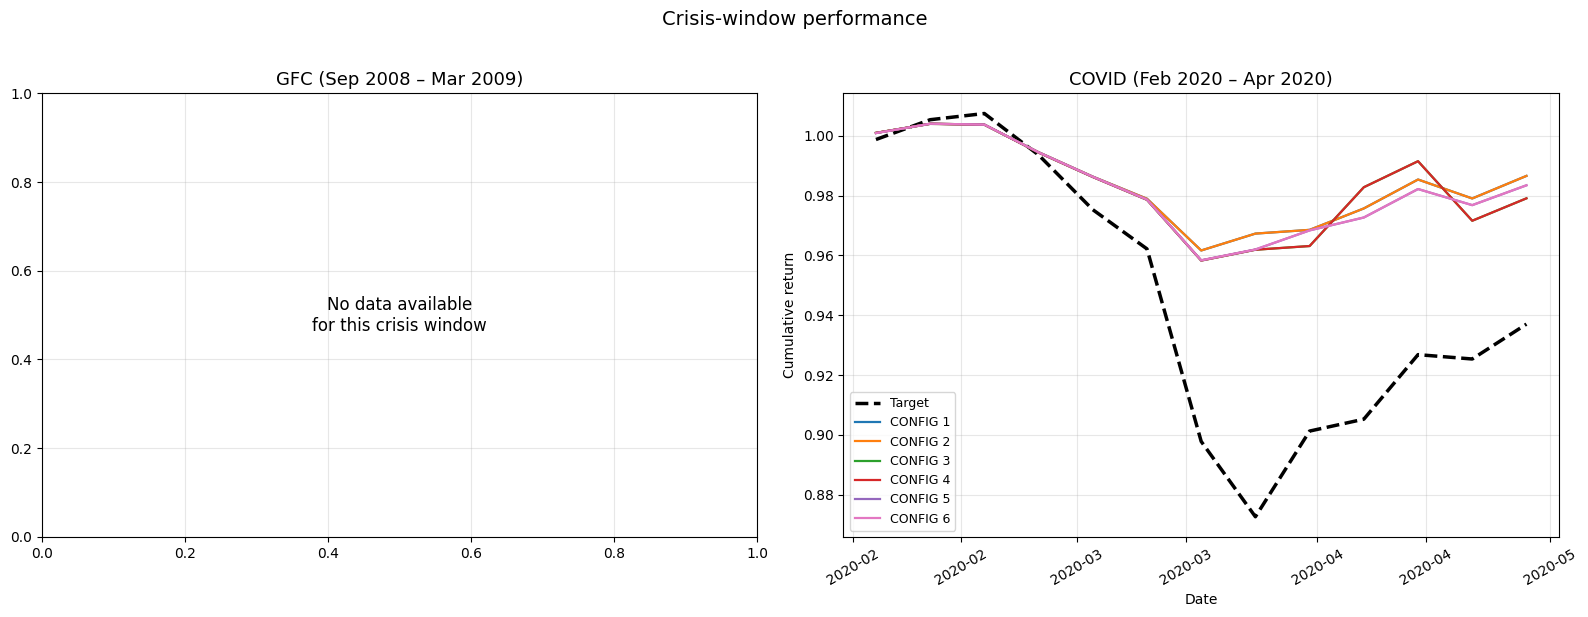

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

crisis_items = list(CRISIS_WINDOWS.items())
colors = plt.cm.tab10(np.linspace(0, 0.6, 6))

for ax, (crisis_name, (start, end)) in zip(axes, crisis_items):

    tgt_slice = results["CONFIG 1"]["target_returns"].loc[start:end]

    if len(tgt_slice) == 0:
        ax.text(
            0.5, 0.5,
            "No data available\nfor this crisis window",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=12
        )
        ax.set_title(crisis_name, fontsize=13)
        ax.grid(True, alpha=0.3)
        continue

    cum_tgt = (1 + tgt_slice).cumprod()
    ax.plot(cum_tgt.index, cum_tgt.values, "k--", lw=2.5, label="Target")

    for (label, res), col in zip(results.items(), colors):
        rr_slice = res["replica_returns"].loc[start:end]

        if len(rr_slice) == 0:
            continue

        cum_rep = (1 + rr_slice).cumprod()
        ax.plot(cum_rep.index, cum_rep.values, lw=1.6, color=col, label=label)

    ax.set_title(crisis_name, fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative return")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Crisis-window performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Turnover and transaction costs

Frequent rebalancing improves monitoring but increases transaction costs (5 basis points per trade). This comparison compares turnover and its impact on the net Information Ratio.

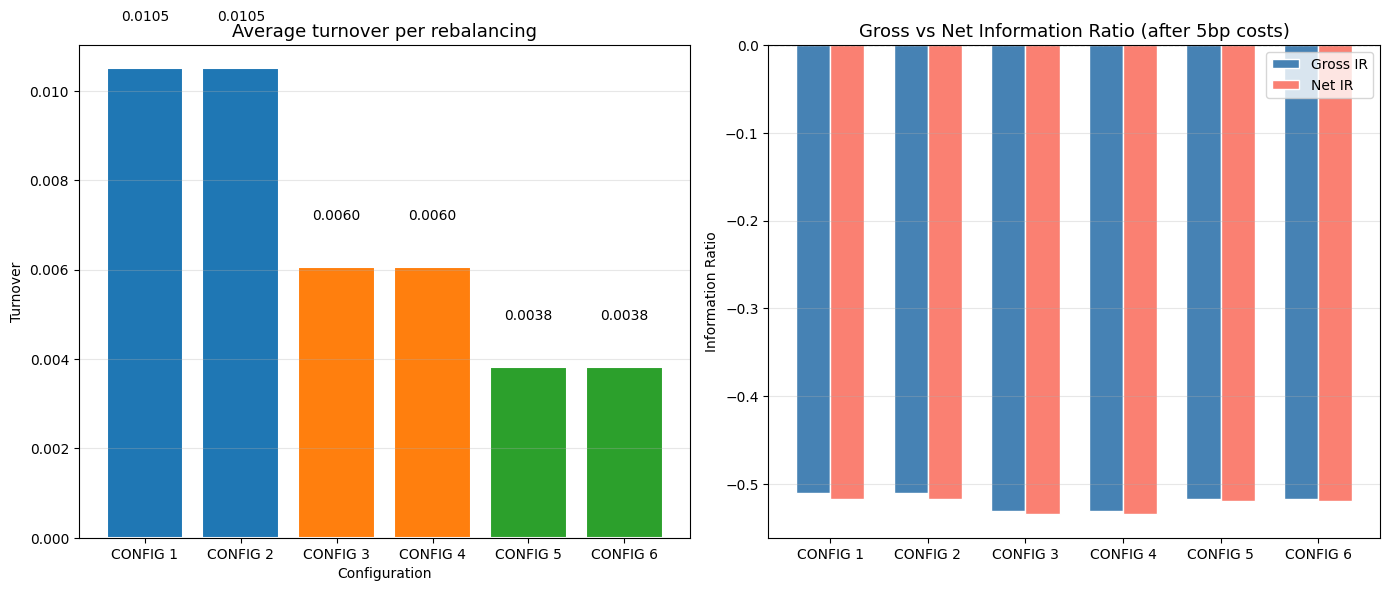


Légend colors : Blue=Weekly, Orange=Monthly, Green=Quarterly
Marker shapes : circle=100% cap, square=200% cap


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels_list  = list(results.keys())
turnovers    = [results[l]['metrics'].loc['turnover','Value'] for l in labels_list]
gross_ir     = [results[l]['metrics'].loc['IR','Value'] for l in labels_list]
net_ir       = [results[l]['metrics'].loc['net_IR','Value'] for l in labels_list]
rebal_freqs  = [results[l]['config']['rebal_freq'] for l in labels_list]
ge_caps      = [results[l]['config']['max_gross_exposure'] for l in labels_list]

cmap_colors = ['#1f77b4' if freq == 1 else '#ff7f0e' if freq == 4 else '#2ca02c'
               for freq in rebal_freqs]
marker_list = ['o' if cap == 1.0 else 's' for cap in ge_caps]

# Turnover
bars = axes[0].bar(labels_list, turnovers, color=cmap_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Average turnover per rebalancing', fontsize=13)
axes[0].set_ylabel('Turnover')
axes[0].set_xlabel('Configuration')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, turnovers):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# IR brut and net
x = np.arange(len(labels_list))
w = 0.35
axes[1].bar(x - w/2, gross_ir, w, label='Gross IR',  color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, net_ir,   w, label='Net IR',    color='salmon',    edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Gross vs Net Information Ratio (after 5bp costs)', fontsize=13)
axes[1].set_ylabel('Information Ratio')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_list)
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print('\nLégend colors : Blue=Weekly, Orange=Monthly, Green=Quarterly')
print('Marker shapes : circle=100% cap, square=200% cap')

## Selection of the best replication strategy

The following section compares all portfolio replication configurations according to several key performance and risk criteria. For each metric, the best-performing configuration is identified and displayed. The evaluated criteria include the Gross Information Ratio (before transaction costs), the Net Information Ratio (after transaction costs), the correlation with the target portfolio, the Tracking Error, the portfolio turnover, and the maximum drawdown.

The final recommended configuration is selected using the Net Information Ratio, since this metric incorporates both replication quality and transaction costs. In practice, a strategy with a high gross performance but excessive turnover may become less attractive once trading costs are taken into account. The selected configuration therefore represents the best trade-off between replication accuracy, stability, and realistic net performance.

In [38]:
criteria = {
    'Best Gross IR':      max(results, key=lambda k: results[k]['metrics'].loc['IR','Value']),
    'Best Net IR':        max(results, key=lambda k: results[k]['metrics'].loc['net_IR','Value']),
    'Best Correlation':   max(results, key=lambda k: results[k]['metrics'].loc['p','Value']),
    'Lowest TE':          min(results, key=lambda k: results[k]['metrics'].loc['TE','Value']),
    'Lowest Turnover':    min(results, key=lambda k: results[k]['metrics'].loc['turnover','Value']),
    'Lowest Drawdown':    min(results, key=lambda k: results[k]['metrics'].loc['mdd','Value']),
}

print('Best configuration by criterion:')
for crit, label in criteria.items():
    m = results[label]['metrics']
    desc = results[label]['config']['desc']
    print(f"  {crit:25s}: {label} ({desc})  IR={m.loc['IR','Value']:+.3f}  TE={m.loc['TE','Value']*100:.2f}%  ρ={m.loc['p','Value']:.3f}")

# Config recommandée = meilleur IR net (coûts inclus)
best_label = criteria['Best Net IR']
print(f'\n Recommended configuration: {best_label} — {results[best_label]["config"]["desc"]}')

Best configuration by criterion:
  Best Gross IR            : CONFIG 1 (Weekly / No leverage)  IR=-0.510  TE=3.83%  ρ=0.780
  Best Net IR              : CONFIG 1 (Weekly / No leverage)  IR=-0.510  TE=3.83%  ρ=0.780
  Best Correlation         : CONFIG 5 (Quarterly / No leverage)  IR=-0.517  TE=3.75%  ρ=0.797
  Lowest TE                : CONFIG 5 (Quarterly / No leverage)  IR=-0.517  TE=3.75%  ρ=0.797
  Lowest Turnover          : CONFIG 5 (Quarterly / No leverage)  IR=-0.517  TE=3.75%  ρ=0.797
  Lowest Drawdown          : CONFIG 1 (Weekly / No leverage)  IR=-0.510  TE=3.83%  ρ=0.780

 Recommended configuration: CONFIG 1 — Weekly / No leverage


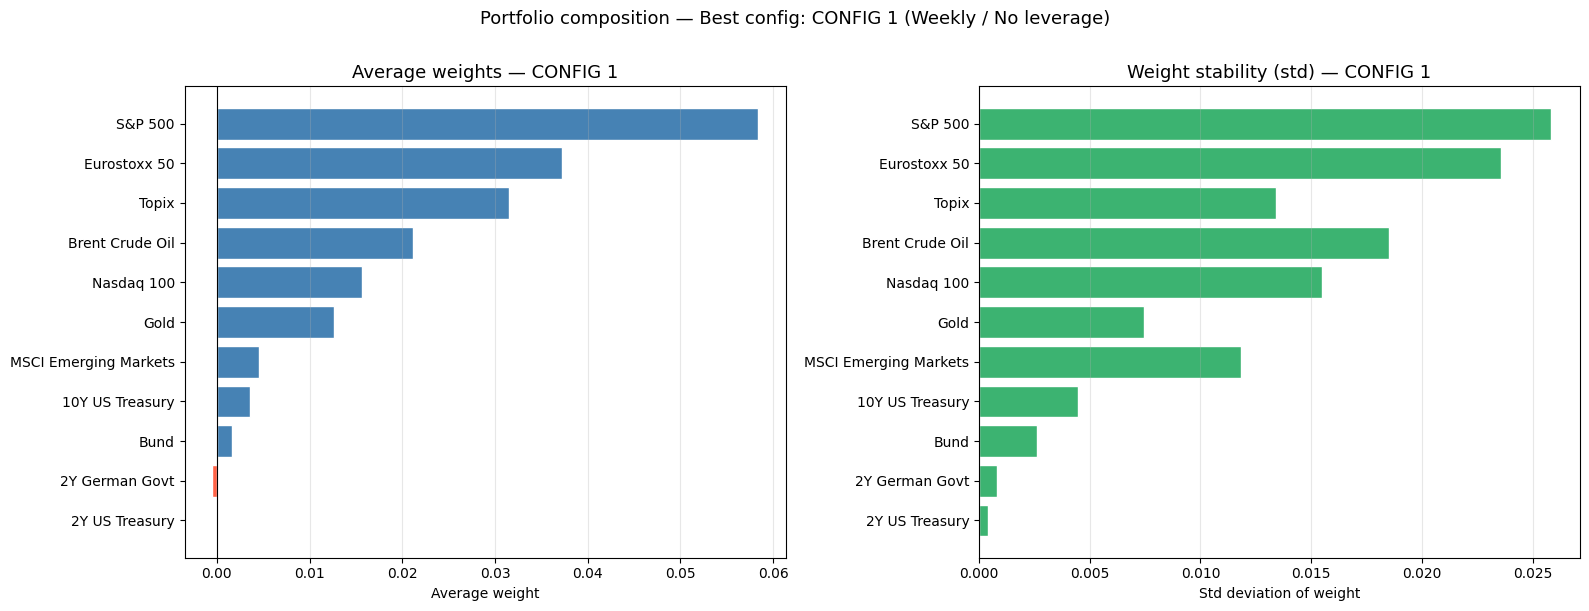

In [39]:
best_wh = results[best_label]['weights_history']
mean_wts = best_wh.mean()
std_wts = best_wh.std()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average weights
sorted_idx = mean_wts.abs().sort_values(ascending=True).index
bars = axes[0].barh(
    [variable_info.get(c, c).split('(')[0].strip() for c in sorted_idx],
    mean_wts[sorted_idx].values,
    color=['tomato' if v < 0 else 'steelblue' for v in mean_wts[sorted_idx].values],
    edgecolor='white'
)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f'Average weights — {best_label}', fontsize=13)
axes[0].set_xlabel('Average weight')
axes[0].grid(True, alpha=0.3, axis='x')

# Weight stability (std)
axes[1].barh(
    [variable_info.get(c, c).split('(')[0].strip() for c in sorted_idx],
    std_wts[sorted_idx].values,
    color='mediumseagreen', edgecolor='white'
)
axes[1].set_title(f'Weight stability (std) — {best_label}', fontsize=13)
axes[1].set_xlabel('Std deviation of weight')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Portfolio composition — Best config: {best_label} ({results[best_label]["config"]["desc"]})',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
# Extended Scenario Search

This section runs an exhaustive grid search over a much wider parameter space — covering rebalancing frequency, leverage cap, ElasticNet regularisation (`alpha`, `l1_ratio`), rolling window length, and VaR budget — to find the best replication strategy beyond the six baseline configurations.  
The same selection criteria used in the baseline analysis (Gross IR, Net IR, Correlation, TE, Turnover, Max Drawdown) are applied to rank and compare every new scenario.

## Scenario grid

`build_scenario_grid()` generates every combination of the chosen hyperparameter values and returns a list of config dicts that are directly accepted by `run_backtest()`.

In [43]:
def build_scenario_grid(
    rebal_freqs = [1, 2, 4, 8, 12],
    gross_exposure_caps = [1.0, 1.5, 2.0],
    alphas = [0.0001, 0.001, 0.01],
    l1_ratios = [0.2, 0.5, 0.8],
    rolling_windows = [52, 104],
    max_vars = [0.06, 0.08, 0.12],
):

    configs = []
    combos  = itertools.product(
        rebal_freqs, gross_exposure_caps, alphas, l1_ratios, rolling_windows, max_vars
    )
    for idx, (rf, ge, a, l1, rw, mv) in enumerate(combos, start=1):
        lev_tag = f"{int(ge*100)}%GE"
        alp_tag = f"a{a}"
        l1_tag = f"L1={l1}"
        rw_tag = f"RW{rw}w"
        mv_tag = f"VaR{int(mv*100)}%"
        freq_tag = {1:"Wkly", 2:"BiWkly", 4:"Mthly", 8:"BiMthly", 12:"Qtrly"}.get(rf, f"{rf}w")
        configs.append({
            'label': f"S{idx:03d}",
            'desc': f"{freq_tag} / {lev_tag} / {alp_tag} / {l1_tag} / {rw_tag} / {mv_tag}",
            'rebal_freq': rf,
            'max_gross_exposure': ge,
            'alpha': a,
            'l1_ratio': l1,
            'rolling_window': rw,
            'max_var': mv,
        })
    return configs

## Scenario runner

`run_scenario_search()` iterates over the full grid, calls `run_backtest()` for each config with all shared parameters (data, cost, VaR horizon, etc.) and stores every result in a dict identical in structure to `results` used above — so all downstream analysis cells work unchanged.

In [45]:
def run_scenario_search(
    configs,
    X_values,
    y_values,
    asset_names,
    dates,
    cost_bps = 5,
    var_confidence = 0.01,
    var_horizon = 4,
    step = 0.005,
    verbose = True,
    verbose_every = 50,
):

    scenario_results = {}
    n = len(configs)

    for i, config in enumerate(configs, start=1):
        label = config['label']

        try:
            result = run_backtest(
                X_values = X_values,
                y_values = y_values,
                asset_names = asset_names,
                dates = dates,
                rolling_window = config['rolling_window'],
                rebal_freq = config['rebal_freq'],
                max_gross_exposure = config['max_gross_exposure'],
                max_var = config['max_var'],
                step = step,
                alpha = config['alpha'],
                l1_ratio = config['l1_ratio'],
                cost_bps = cost_bps,
                var_confidence = var_confidence,
                var_horizon = var_horizon,
            )

            scenario_results[label] = {'config': config, **result}

            if verbose and (i % verbose_every == 0 or i == n):
                m = result['metrics']
                IR = m.loc['IR', 'Value']
                TE = m.loc['TE', 'Value']
                rho = m.loc['p', 'Value']
                print(f"  [{i:>4}/{n}]  {label}  IR={IR:+.3f}  TE={TE*100:.2f}%  ρ={rho:.3f}  — {config['desc']}")

        except Exception as e:
            if verbose:
                print(f"  [{i:>4}/{n}]  {label}  ✗ ERROR: {e}")

    print(f"\n Completed {len(scenario_results)}/{n} scenarios successfully.")
    return scenario_results

## Launch the search

Running all scenarios takes a few minutes. Progress is printed every 50 iterations.

In [46]:
grid = build_scenario_grid(
    rebal_freqs = [1, 2, 4, 8, 12],
    gross_exposure_caps = [1.0, 1.5, 2.0],
    alphas = [0.0001, 0.001, 0.01],
    l1_ratios = [0.2, 0.5, 0.8],
    rolling_windows = [52, 104],
    max_vars = [0.06, 0.08, 0.12],
)

scenario_results = run_scenario_search(
    configs = grid,
    X_values = X_values,
    y_values = y_values,
    asset_names = asset_names,
    dates = dates,
    cost_bps = 5,
    var_confidence = 0.01,
    var_horizon = 4,
    step = 0.005,
    verbose = True,
    verbose_every = 50,
)

Launching grid search over 810 scenarios…

  [  50/810]  S050  IR=-0.682  TE=4.31%  ρ=0.760  — Wkly / 100%GE / a0.01 / L1=0.8 / RW52w / VaR8%
  [ 100/810]  S100  IR=-0.501  TE=3.94%  ρ=0.772  — Wkly / 150%GE / a0.01 / L1=0.5 / RW104w / VaR6%
  [ 150/810]  S150  IR=-0.462  TE=3.92%  ρ=0.757  — Wkly / 200%GE / a0.01 / L1=0.2 / RW104w / VaR12%
  [ 200/810]  S200  IR=-0.597  TE=4.28%  ρ=0.732  — BiWkly / 100%GE / a0.01 / L1=0.2 / RW52w / VaR8%
  [ 250/810]  S250  IR=-0.500  TE=3.83%  ρ=0.780  — BiWkly / 150%GE / a0.001 / L1=0.8 / RW104w / VaR6%
  [ 300/810]  S300  IR=-0.481  TE=3.86%  ρ=0.770  — BiWkly / 200%GE / a0.001 / L1=0.5 / RW104w / VaR12%
  [ 350/810]  S350  IR=-0.631  TE=4.26%  ρ=0.736  — Mthly / 100%GE / a0.001 / L1=0.5 / RW52w / VaR8%
  [ 400/810]  S400  IR=-0.516  TE=3.82%  ρ=0.770  — Mthly / 150%GE / a0.001 / L1=0.2 / RW104w / VaR6%
  [ 450/810]  S450  IR=-0.564  TE=3.81%  ρ=0.769  — Mthly / 200%GE / a0.0001 / L1=0.8 / RW104w / VaR12%
  [ 500/810]  S500  IR=-0.614  TE=4.25%  ρ

## Best-scenario selector

`select_best_scenarios()` applies the **exact same six criteria** used in the baseline section and additionally computes a composite score so that a single "overall best" scenario can be recommended.

In [47]:
def select_best_scenarios(scenario_results):
    
    criteria = {
        'Best Gross IR': max(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['IR', 'Value']),
        'Best Net IR': max(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['net_IR', 'Value']),
        'Best Correlation': max(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['p', 'Value']),
        'Lowest TE': min(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['TE', 'Value']),
        'Lowest Turnover': min(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['turnover', 'Value']),
        'Lowest Drawdown': min(scenario_results, key=lambda k: scenario_results[k]['metrics'].loc['mdd', 'Value']),
    }

    # Build scored DataFrame
    rows = []
    for label, res in scenario_results.items():
        m = res['metrics']
        cfg = res['config']
        rows.append({
            'label': label,
            'desc': cfg['desc'],
            'IR': m.loc['IR', 'Value'],
            'net_IR': m.loc['net_IR', 'Value'],
            'p': m.loc['p', 'Value'],
            'TE': m.loc['TE', 'Value'],
            'turnover': m.loc['turnover', 'Value'],
            'mdd': m.loc['mdd', 'Value'],
            'rep_ann': m.loc['rep_ann', 'Value'],
            'rep_vol': m.loc['rep_vol', 'Value'],
            'sharpe': m.loc['sharpe', 'Value'],
            'GE': m.loc['GE', 'Value'],
            'VaR': m.loc['VaR', 'Value'],
        })

    df = pd.DataFrame(rows).set_index('label')

    # Z-score normalisation (higher = better for all, negate cost metrics)
    for col in ['IR', 'net_IR', 'p']:
        df[f'z_{col}'] = (df[col] - df[col].mean()) / (df[col].std() + 1e-12)
    for col in ['TE', 'turnover', 'mdd']:
        df[f'z_{col}'] = -(df[col] - df[col].mean()) / (df[col].std() + 1e-12)

    z_cols = ['z_IR', 'z_net_IR', 'z_p', 'z_TE', 'z_turnover', 'z_mdd']
    df['composite_score'] = df[z_cols].mean(axis=1)
    df = df.sort_values('composite_score', ascending=False)

    return criteria, df


scenario_criteria, scored_df = select_best_scenarios(scenario_results)

## Per-criterion winners

In [48]:
print("Best scenario by criterion:")

for crit, label in scenario_criteria.items():
    m = scenario_results[label]['metrics']
    desc = scenario_results[label]['config']['desc']
    IR = m.loc['IR', 'Value']
    TE = m.loc['TE', 'Value']
    rho = m.loc['p', 'Value']
    nIR = m.loc['net_IR', 'Value']
    print(f" {crit:22s} {label}  IR={IR:+.3f}  Net IR={nIR:+.3f}  TE={TE*100:.2f}%  ρ={rho:.3f}")
    print(f" {'':22s}   {desc}")
    print()

# Overall best (composite score)
overall_best_label = scored_df.index[0]
overall_best_score = scored_df['composite_score'].iloc[0]
ob = scenario_results[overall_best_label]
m = ob['metrics']

print(f" OVERALL BEST (composite score = {overall_best_score:.3f})")
print(f" Label : {overall_best_label}")
print(f" Config: {ob['config']['desc']}")
print(f" IR={m.loc['IR','Value']:+.3f}  Net IR={m.loc['net_IR','Value']:+.3f}  "
      f" TE={m.loc['TE','Value']*100:.2f}%  ρ={m.loc['p','Value']:.3f}  "
      f" MDD={m.loc['mdd','Value']*100:.2f}%  Turnover={m.loc['turnover','Value']:.4f}")


Best scenario by criterion:
 Best Gross IR          S527  IR=-0.368  Net IR=-0.370  TE=4.19%  ρ=0.674
                          BiMthly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%

 Best Net IR            S527  IR=-0.368  Net IR=-0.370  TE=4.19%  ρ=0.674
                          BiMthly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%

 Best Correlation       S700  IR=-0.534  Net IR=-0.536  TE=3.97%  ρ=0.806
                          Qtrly / 100%GE / a0.01 / L1=0.8 / RW104w / VaR6%

 Lowest TE              S665  IR=-0.512  Net IR=-0.515  TE=3.74%  ρ=0.793
                          Qtrly / 100%GE / a0.0001 / L1=0.8 / RW104w / VaR8%

 Lowest Turnover        S688  IR=-0.486  Net IR=-0.488  TE=3.82%  ρ=0.789
                          Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR6%

 Lowest Drawdown        S004  IR=-0.511  Net IR=-0.520  TE=3.87%  ρ=0.761
                          Wkly / 100%GE / a0.0001 / L1=0.2 / RW104w / VaR6%

 OVERALL BEST (composite score = 1.117)
 Label : S599
 Config: Bi

## Top-20 scenarios: full metrics table

In [49]:
top20 = scored_df.head(20).copy()

display_cols = ['desc','IR','net_IR','p','TE','turnover','mdd','sharpe','rep_ann','composite_score']
top20_display = top20[display_cols].copy()

# Format for readability
fmt = {
    'IR': '{:+.3f}'.format,
    'net_IR': '{:+.3f}'.format,
    'p': '{:.4f}'.format,
    'TE': lambda x: f'{x*100:.2f}%',
    'turnover': '{:.4f}'.format,
    'mdd': lambda x: f'{x*100:.2f}%',
    'sharpe': '{:.3f}'.format,
    'rep_ann': lambda x: f'{x*100:+.2f}%',
    'composite_score': '{:.3f}'.format,
}

for col, fn in fmt.items():
    top20_display[col] = top20_display[col].apply(fn)

top20_display.columns = ['Description','Gross IR','Net IR','ρ','TE','Turnover',
                          'Max DD','Sharpe','Ann. Return','Composite Score']


print("TOP 20 SCENARIOS: ranked by composite score")
display(top20_display)

TOP 20 SCENARIOS: ranked by composite score


,Description,Gross IR,Net IR,ρ,TE,Turnover,Max DD,Sharpe,Ann. Return,Composite Score
label,,,,,,,,,,
S599,BiMthly / 200%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S600,BiMthly / 200%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S545,BiMthly / 150%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S546,BiMthly / 150%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S491,BiMthly / 100%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S492,BiMthly / 100%GE / a0.0001 / L1=0.2 / RW104w /...,-0.460,-0.464,0.7860,3.76%,0.0059,4.64%,0.719,+2.15%,1.117
S742,Qtrly / 150%GE / a0.01 / L1=0.2 / RW104w / VaR6%,-0.486,-0.488,0.7889,3.82%,0.0024,4.39%,0.722,+2.01%,1.116
S689,Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%,-0.486,-0.488,0.7889,3.82%,0.0024,4.39%,0.722,+2.01%,1.116
S743,Qtrly / 150%GE / a0.01 / L1=0.2 / RW104w / VaR8%,-0.486,-0.488,0.7889,3.82%,0.0024,4.39%,0.722,+2.01%,1.116


## Visualisations

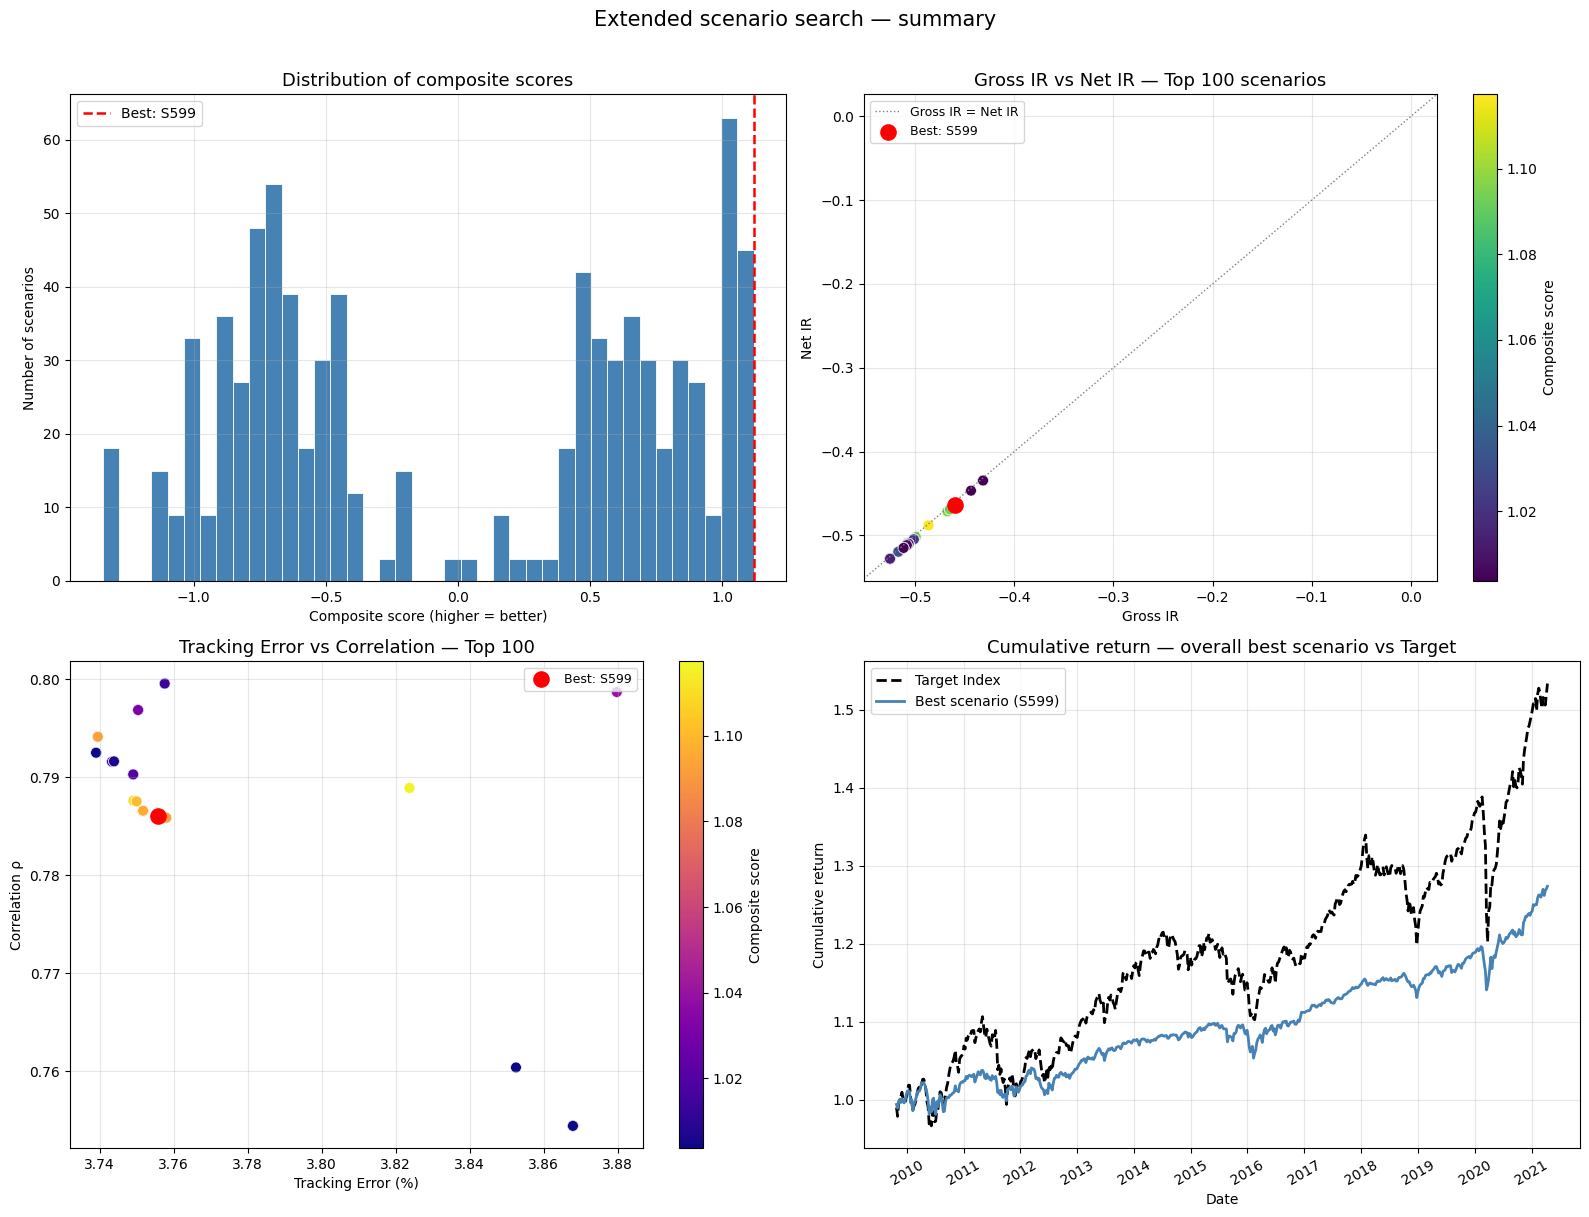

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Composite score distribution
axes[0, 0].hist(scored_df['composite_score'], bins=40, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0, 0].axvline(scored_df['composite_score'].iloc[0], color='red', ls='--', lw=1.8,
                    label=f'Best: {overall_best_label}')
axes[0, 0].set_title('Distribution of composite scores', fontsize=13)
axes[0, 0].set_xlabel('Composite score (higher = better)')
axes[0, 0].set_ylabel('Number of scenarios')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Gross IR vs Net IR scatter (top 100)
top100 = scored_df.head(100)
sc = axes[0, 1].scatter(top100['IR'], top100['net_IR'],
                         c=top100['composite_score'], cmap='viridis',
                         s=60, edgecolors='white', linewidths=0.4)
axes[0, 1].axline((0, 0), slope=1, color='grey', ls=':', lw=1, label='Gross IR = Net IR')
axes[0, 1].scatter(scored_df.loc[overall_best_label,'IR'],
                    scored_df.loc[overall_best_label,'net_IR'],
                    color='red', s=120, zorder=5, label=f'Best: {overall_best_label}')
plt.colorbar(sc, ax=axes[0, 1], label='Composite score')
axes[0, 1].set_title('Gross IR vs Net IR — Top 100 scenarios', fontsize=13)
axes[0, 1].set_xlabel('Gross IR'); axes[0, 1].set_ylabel('Net IR')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=0.3)

# TE vs Correlation scatter (top 100)
sc2 = axes[1, 0].scatter(top100['TE'] * 100, top100['p'],
                          c=top100['composite_score'], cmap='plasma',
                          s=60, edgecolors='white', linewidths=0.4)
axes[1, 0].scatter(scored_df.loc[overall_best_label,'TE'] * 100,
                    scored_df.loc[overall_best_label,'p'],
                    color='red', s=120, zorder=5, label=f'Best: {overall_best_label}')
plt.colorbar(sc2, ax=axes[1, 0], label='Composite score')
axes[1, 0].set_title('Tracking Error vs Correlation — Top 100', fontsize=13)
axes[1, 0].set_xlabel('Tracking Error (%)'); axes[1, 0].set_ylabel('Correlation ρ')
axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, alpha=0.3)

# Cumulative return — overall best vs target
best_res   = scenario_results[overall_best_label]
cum_rep    = (1 + best_res['replica_returns']).cumprod()
cum_tgt    = (1 + best_res['target_returns']).cumprod()
axes[1, 1].plot(cum_tgt.index, cum_tgt.values, 'k--', lw=2, label='Target Index')
axes[1, 1].plot(cum_rep.index, cum_rep.values, color='steelblue', lw=2,
                label=f'Best scenario ({overall_best_label})')
axes[1, 1].set_title('Cumulative return — overall best scenario vs Target', fontsize=13)
axes[1, 1].set_xlabel('Date'); axes[1, 1].set_ylabel('Cumulative return')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Extended scenario search — summary', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()